Measuring Cell-level state

In [1]:
import os
# os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap


# Initialize NACCell
nsac = OUWrap(NAC(d_model=16, num_heads=2,topk=8),
              output_dim=1,
              return_attention=True,
              return_sequences=False,
              return_cell_state=True)

def get_neuron_groups(rnn_layer):
    return {
        "sensory": rnn_layer.cell.sensory_indices,
        "inter": rnn_layer.cell.inter_indices,
        "command": rnn_layer.cell.command_indices,
        "motor": rnn_layer.cell.motor_indices
    }

# Dummy input and forwadpass
np.random.seed(42)
dummy_input = np.random.uniform(-1, 1, (1, 20, 16)).astype(np.float32)
mean, std, weights, cell_states = nsac(dummy_input)

print("Mean shape:", mean.shape)
print("Std shape:", std.shape)
print("Attention weights shape:", weights.shape)

print("Cell states keys:", cell_states.keys())

row_index = []
for gate_name, voltages in cell_states.items():
    groups = get_neuron_groups(getattr(nsac, gate_name))
    for group_name, indices in groups.items():
        for idx in indices:
            trajectory = voltages[0, :, idx].numpy()
            if np.any(trajectory != 0):  # include only non-zero neurons
                row_index.append((gate_name, group_name, idx))

multi_index = pd.MultiIndex.from_tuples(row_index, names=["gate", "group", "neuron_idx"])
df = pd.DataFrame(index=multi_index, columns=[f"step_{i}" for i in range(20)])

# Fill DataFrame with trajectories
for gate_name, voltages in cell_states.items():
    groups = get_neuron_groups(getattr(nsac, gate_name))
    print(f"\nNeuron voltages for {gate_name}:")
    for group_name, indices in groups.items():
        for idx in indices:
            trajectory = voltages[0, :, idx].numpy()
            if np.any(trajectory != 0):
                print(f"{gate_name} - {group_name} neuron {idx}: {trajectory}")
                df.loc[(gate_name, group_name, idx), :] = trajectory

# Save to CSV
df.to_csv('nsac_cell_states.csv')


2026-05-19 19:14:00.066560: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 19:14:00.078555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779189240.092193   26821 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779189240.096299   26821 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 19:14:00.110736: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Mean shape: (1, 1)
Std shape: (1, 1)
Attention weights shape: (1, 2, 20, 8)
Cell states keys: dict_keys(['ncp_out', 'q_proj', 'k_proj', 'v_proj'])

Neuron voltages for ncp_out:
ncp_out - inter neuron 12: [ 0.2906454  -0.06290766  0.1983976   0.21870837  0.28512275  0.13608718
  0.09406232 -0.2316754   0.23882048  0.486381    0.2030036   0.33954015
 -0.01932617  0.1463384  -0.01051041  0.35987225 -0.38555843 -0.1724095
 -0.5071072  -0.28112763]
ncp_out - inter neuron 14: [ 0.18164527  0.01011133 -0.59691703 -0.22642271 -1.0000439   0.46147725
  0.078142    0.01021579 -0.4313936  -0.42935008 -0.45969987  0.01526739
  0.202795   -0.503588   -0.15331385  0.29819548  0.5508233   0.28570816
  0.20056751  0.024601  ]
ncp_out - inter neuron 15: [-0.2249317  -0.37753585 -0.08103181 -0.21265769  0.01526852  0.13187048
 -0.62822306  0.2887371   0.10850865  0.07954551  0.16978344  0.3040838
 -0.25547656 -0.40247685 -0.14981061  0.52276564  0.42309815  0.1084303
 -0.32345513  0.23580153]
ncp_out - 

Visualize Cell states

2026-05-19 19:17:01.438660: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 19:17:01.450407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779189421.464078   28811 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779189421.468155   28811 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 19:17:01.481790: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

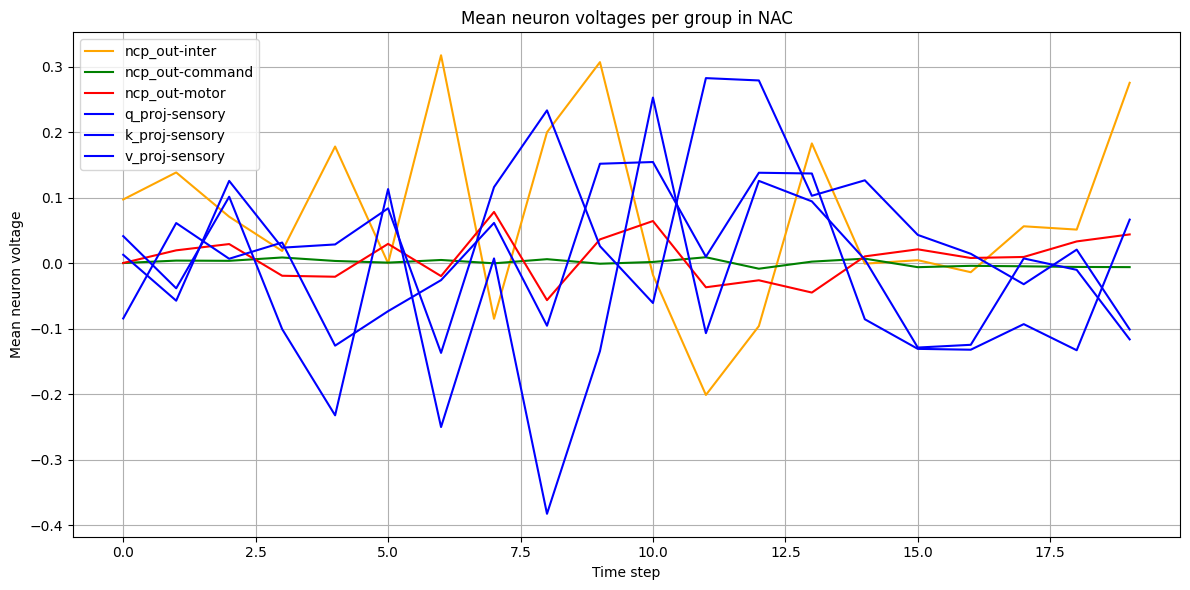

In [1]:
import os
# os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from neuronal_attention_circuit import NAC
from ouwrap import OUWrap


# Initialize NACCell
nsac = OUWrap(NAC(d_model=16, num_heads=2,topk=8),
              output_dim=1,
              return_cell_state=True)

# Dummy input
dummy_input = np.random.uniform(-1, 1, (1, 20, 16)).astype(np.float32)
mean, std, cell_states = nsac(dummy_input)

# Map neuron indices to groups
def get_neuron_groups(rnn_layer):
    return {
        "sensory": rnn_layer.cell.sensory_indices,
        "inter": rnn_layer.cell.inter_indices,
        "command": rnn_layer.cell.command_indices,
        "motor": rnn_layer.cell.motor_indices
    }

# Compute and plot mean voltage per group
time = np.arange(20)
plt.figure(figsize=(12, 6))

colors = {
    "sensory": "blue",
    "inter": "orange",
    "command": "green",
    "motor": "red"
}

for gate_name, voltages in cell_states.items():
    groups = get_neuron_groups(getattr(nsac, gate_name))
    for group_name, indices in groups.items():
        if len(indices) == 0:
            continue
        group_indices = tf.constant(indices, dtype=tf.int32)  # convert to Tensor
        group_voltages = tf.gather(voltages[0], group_indices, axis=-1)  # [T, num_neurons]
        group_voltages = group_voltages.numpy()

        # Skip if all zeros
        if np.all(group_voltages == 0):
            continue
        mean_trajectory = np.mean(group_voltages, axis=1)
        plt.plot(time, mean_trajectory, label=f"{gate_name}-{group_name}", color=colors.get(group_name, "black"))


plt.xlabel("Time step")
plt.ylabel("Mean neuron voltage")
plt.title("Mean neuron voltages per group in NAC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Testing Sensorygate projections

Sensory: [13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31]
Inter: []
Command: []
Motor (output only): []


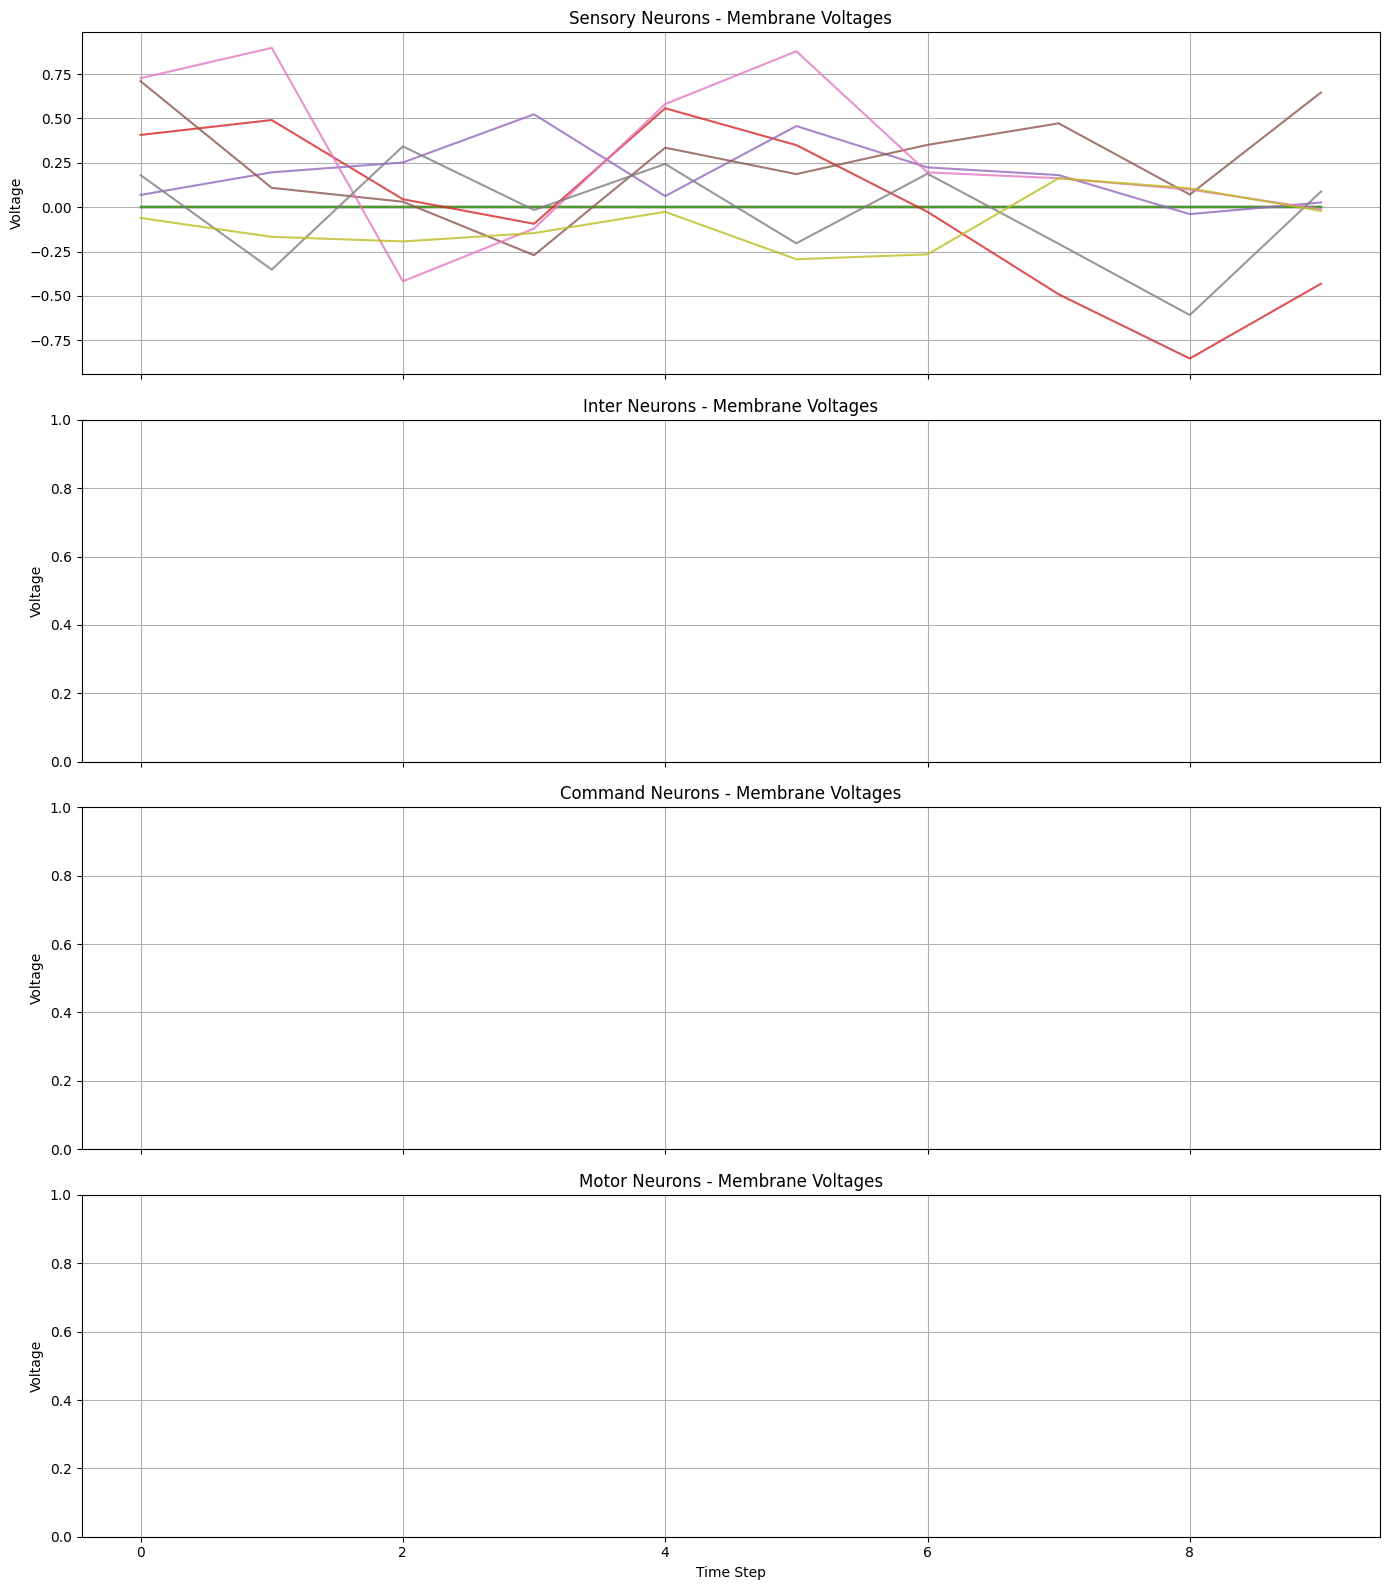

In [2]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
tf.config.run_functions_eagerly(True)  # Forces eager execution

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from ncps.wirings import AutoNCP
from neuronal_attention_circuit import NCPCell

# AutoNCP configuration
total_hidden_neurons = 32
motor_neurons_count = 1
input_features = 8
time_steps = 10
batch_size = 1
sparsity_level = 0.9

wiring = AutoNCP(total_hidden_neurons, motor_neurons_count, sparsity_level=sparsity_level)
cell = NCPCell(
    wiring,
    activation="linear",
    input_group="sensory",
    output_group="sensory",
    disabled_groups=["inter", "command", "motor"]  # disable these groups
)
cell.build(input_shape=(None, input_features))

# Active neuron indices
def get_active_neurons(cell):
    active = cell.active_mask.numpy()
    sensory_neurons = cell.sensory_indices[active[cell.sensory_indices] > 0]
    inter_neurons = cell.inter_indices[active[cell.inter_indices] > 0]
    command_neurons = cell.command_indices[active[cell.command_indices] > 0]
    motor_neurons = cell.motor_indices[active[cell.motor_indices] > 0]
    return sensory_neurons, inter_neurons, command_neurons, motor_neurons

sensory_neurons, inter_neurons, command_neurons, active_motor_indices = get_active_neurons(cell)

print(f"Sensory: {sensory_neurons}")
print(f"Inter: {inter_neurons}")
print(f"Command: {command_neurons}")
print(f"Motor (output only): {active_motor_indices}")

# Extract hidden neuron voltages
def extract_hidden_voltages(inputs, cell):
    if isinstance(inputs, np.ndarray):
        inputs = tf.convert_to_tensor(inputs, dtype=tf.float32)

    batch_size = tf.shape(inputs)[0]
    time_steps = tf.shape(inputs)[1]

    state = cell.get_initial_state(batch_size=batch_size, dtype=tf.float32)
    voltages = []

    for t in range(time_steps):
        x_t = inputs[:, t, :]
        _, [state] = cell(x_t, [state])
        voltages.append(state)

    voltages = tf.stack(voltages, axis=1)[0]  # assumes batch_size=1
    return voltages.numpy()

# Dummy input
dummy_inputs = np.random.uniform(-1, 1, (batch_size, time_steps, input_features)).astype(np.float32)
voltages = extract_hidden_voltages(dummy_inputs, cell)
time = np.arange(time_steps)

# Plot hidden neuron voltages
groups = [
    ("Sensory Neurons", sensory_neurons),
    ("Inter Neurons", inter_neurons),
    ("Command Neurons", command_neurons),
    ("Motor Neurons", active_motor_indices)
]

# only create subplots for non-empty groups
# non_empty_groups = [g for g in groups if len(g[1]) > 0]
fig, axs = plt.subplots(len(groups), 1, figsize=(14, 4*len(groups)), sharex=True)
if len(groups) == 1:
    axs = [axs]

start_idx = 0
for ax, (title, indices) in zip(axs, groups):
    for i in range(len(indices)):
        ax.plot(time, voltages[:, start_idx + i], alpha=0.8)
    ax.set_title(f"{title} - Membrane Voltages")
    ax.set_ylabel("Voltage")
    ax.grid(True)
    start_idx += len(indices)

axs[-1].set_xlabel("Time Step")
plt.tight_layout()
plt.show()



Sensory: []
Inter: [ 3  4  6  7  8  9 11 12 13]
Command: [ 5 10]
Motor (output only): [0 1 2]


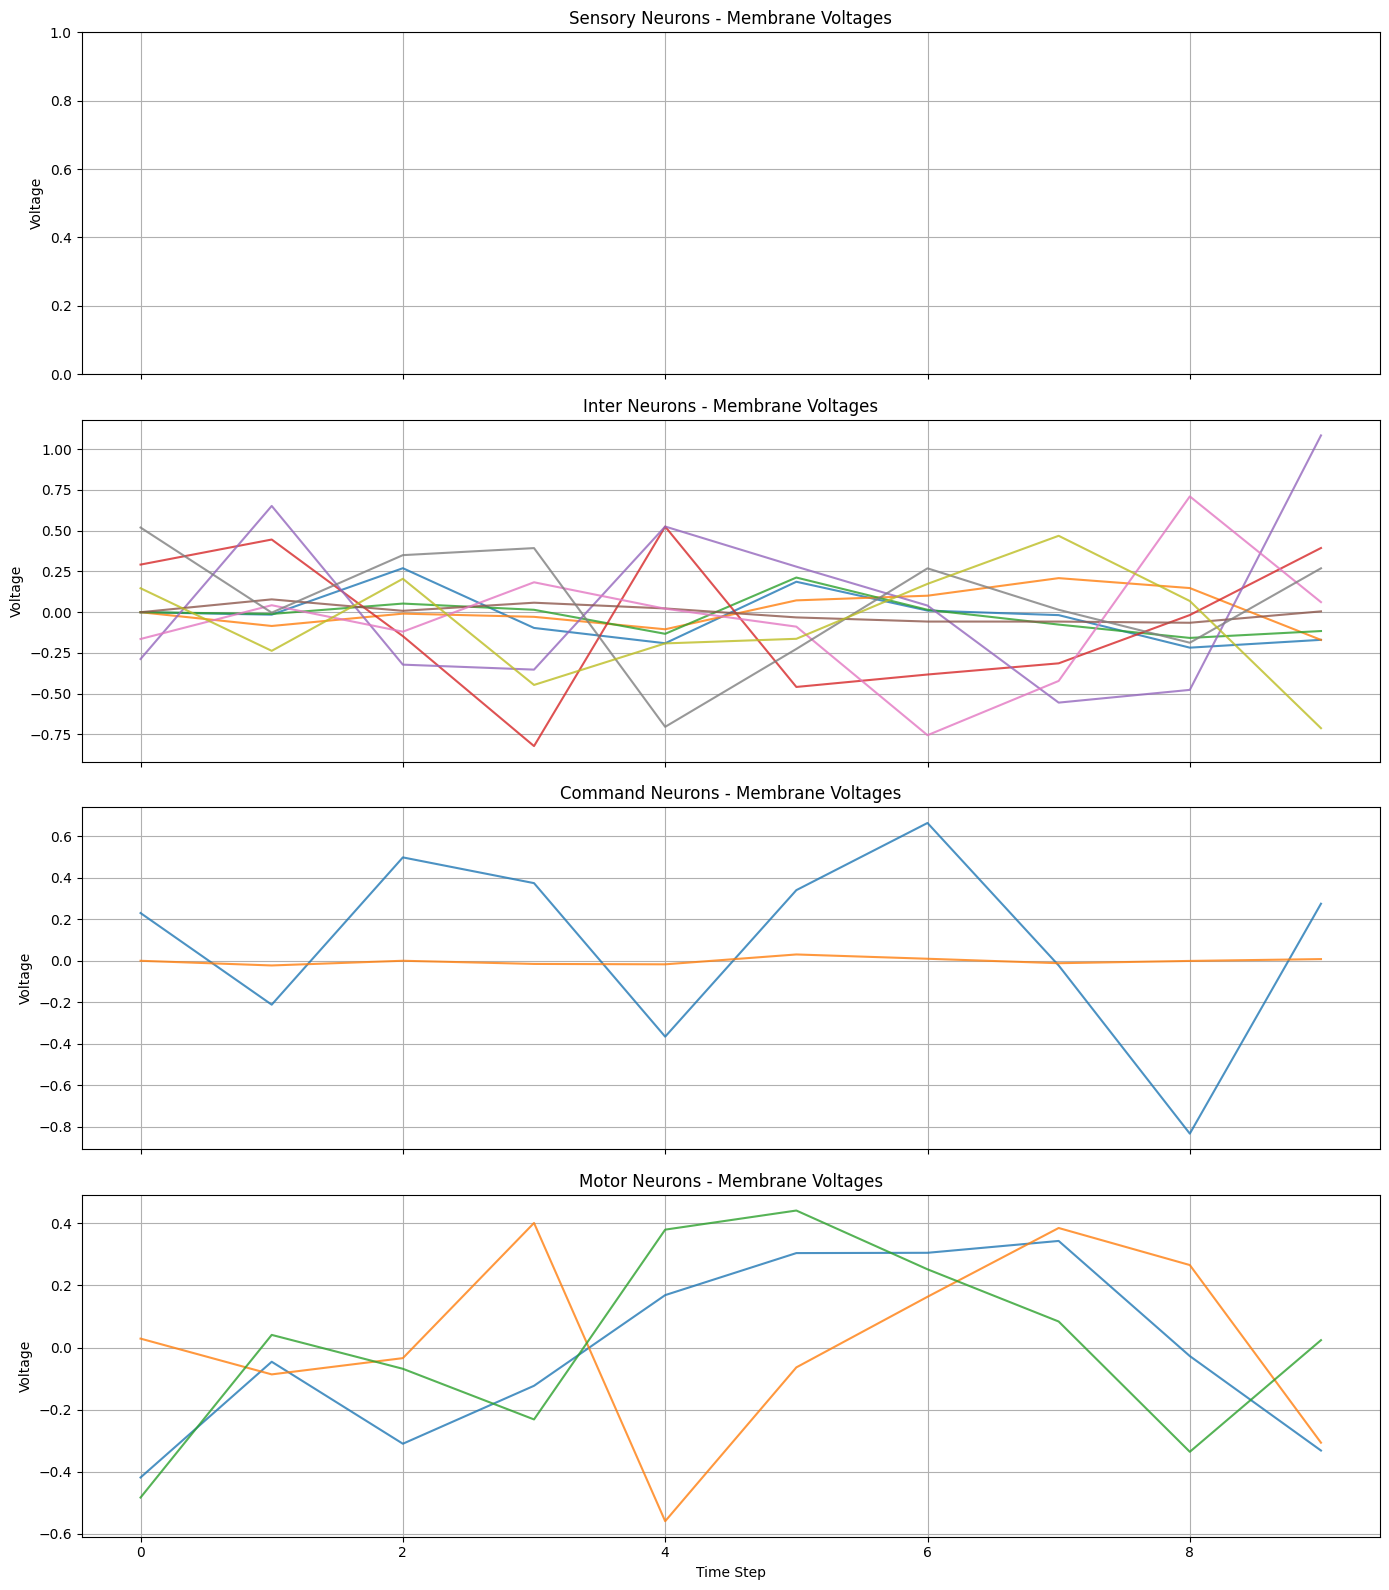

In [3]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
tf.config.run_functions_eagerly(True)  # Forces eager execution

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from ncps.wirings import AutoNCP
from neuronal_attention_circuit import NCPCell

# AutoNCP configuration
total_hidden_neurons = 32
motor_neurons_count = 3
input_features = 8
time_steps = 10
batch_size = 1
sparsity_level = 0.9

wiring = AutoNCP(total_hidden_neurons, motor_neurons_count, sparsity_level=sparsity_level)
cell = NCPCell(
    wiring,
    activation="linear",
    input_group="inter",
    output_group="motor",
    disabled_groups=["sensory"]  # disable these groups
)
cell.build(input_shape=(None, input_features))

# Active neuron indices
def get_active_neurons(cell):
    active = cell.active_mask.numpy()
    sensory_neurons = cell.sensory_indices[active[cell.sensory_indices] > 0]
    inter_neurons = cell.inter_indices[active[cell.inter_indices] > 0]
    command_neurons = cell.command_indices[active[cell.command_indices] > 0]
    motor_neurons = cell.motor_indices[active[cell.motor_indices] > 0]
    return sensory_neurons, inter_neurons, command_neurons, motor_neurons

sensory_neurons, inter_neurons, command_neurons, active_motor_indices = get_active_neurons(cell)

print(f"Sensory: {sensory_neurons}")
print(f"Inter: {inter_neurons}")
print(f"Command: {command_neurons}")
print(f"Motor (output only): {active_motor_indices}")

# Extract hidden neuron voltages
def extract_hidden_voltages(inputs, cell):
    if isinstance(inputs, np.ndarray):
        inputs = tf.convert_to_tensor(inputs, dtype=tf.float32)

    batch_size = tf.shape(inputs)[0]
    time_steps = tf.shape(inputs)[1]

    state = cell.get_initial_state(batch_size=batch_size, dtype=tf.float32)
    voltages = []

    for t in range(time_steps):
        x_t = inputs[:, t, :]
        _, [state] = cell(x_t, [state])
        voltages.append(state)

    voltages = tf.stack(voltages, axis=1)[0]  # assumes batch_size=1
    return voltages.numpy()

# Dummy input
dummy_inputs = np.random.uniform(-1, 1, (batch_size, time_steps, input_features)).astype(np.float32)
voltages = extract_hidden_voltages(dummy_inputs, cell)
time = np.arange(time_steps)

# Plot hidden neuron voltages
groups = [
    ("Sensory Neurons", sensory_neurons),
    ("Inter Neurons", inter_neurons),
    ("Command Neurons", command_neurons),
    ("Motor Neurons", active_motor_indices)
]

# only create subplots for non-empty groups
# non_empty_groups = [g for g in groups if len(g[1]) > 0]
fig, axs = plt.subplots(len(groups), 1, figsize=(14, 4*len(groups)), sharex=True)
if len(groups) == 1:
    axs = [axs]

start_idx = 0
for ax, (title, indices) in zip(axs, groups):
    for i in range(len(indices)):
        ax.plot(time, voltages[:, start_idx + i], alpha=0.8)
    ax.set_title(f"{title} - Membrane Voltages")
    ax.set_ylabel("Voltage")
    ax.grid(True)
    start_idx += len(indices)

axs[-1].set_xlabel("Time Step")
plt.tight_layout()
plt.show()

